In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import time, os, sys
from glob import glob
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from photutils.psf import fit_2dgaussian
from photutils.centroids import centroid_com, centroid_1dg
from skimage import transform

from hcipy import *
from hcipy.metrics import get_strehl_from_focal
from hcipy.aperture import make_keck_aperture

# Import my CD5 utils
sys.path.append('/Users/isabelkain/Desktop/SCALES/CD5')
sys.path.append('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool')
from cd5_utils import *
from utils import *
from do_psf_fitting import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

## Functions

In [31]:
def make_lyot_stop(whichmask='3%'):

    # Construct Lyot pupil: outer diameter
    pupil_diameter = 10.95  # m actual circumscribed diameter

    # Hex segments
    actual_segment_flat_diameter = np.sqrt(3) / 2 * 1.8  # m actual segment flat-to-flat diameter
    actual_segment_gap = 0.003  # m actual gap size between segments
    num_rings = 3  # number of full rings of hexagons around central segment
    segment_transmissions = 1.0
    
    # Lyot masks are undersized compared to the Keck pupil. 
    # Adjust dimensions based on whether this is the 1%, 2% or 3% Lyot mask
    
    if whichmask=='1%':
        
        # Reduce pupil outer diameter by 3%
        pupil_diameter *= 0.99
    
        # Secondary obscuration & spiders
        central_obscuration_diameter = 2.5413  # m
        spider_width = 0.1348 # m
        
    elif whichmask=='2%':
        
        # Reduce pupil outer diameter by 3%
        pupil_diameter *= 0.98
    
        # Secondary obscuration & spiders
        central_obscuration_diameter = 2.6243  # m
        spider_width = 0.2386 # m
        
    elif whichmask=='3%':
        
        # Reduce pupil outer diameter by 3%
        pupil_diameter *= 0.97
    
        # Secondary obscuration & spiders
        central_obscuration_diameter = 2.7487  # m
        spider_width = 0.3423 # m

    
    # Normalize s.t. pupil diameter = 1.0
    actual_segment_flat_diameter /= pupil_diameter
    actual_segment_gap /= pupil_diameter
    spider_width /= pupil_diameter
    central_obscuration_diameter /= pupil_diameter
    pupil_diameter = 1.0


    # Segments
    segment_gap = 0

    segment_flat_diameter = actual_segment_flat_diameter - (segment_gap - actual_segment_gap)
    segment_circum_diameter = 2 / np.sqrt(3) * segment_flat_diameter

    segment_positions = make_hexagonal_grid(actual_segment_flat_diameter + actual_segment_gap, num_rings)

    segment = make_hexagonal_aperture(segment_circum_diameter, np.pi / 2)


    # Spiders
    spider1 = make_spider_infinite([0, 0], 30+30., spider_width)
    spider2 = make_spider_infinite([0, 0], 90+30., spider_width)
    spider3 = make_spider_infinite([0, 0], 150+30., spider_width)
    spider4 = make_spider_infinite([0, 0], 210+30., spider_width)
    spider5 = make_spider_infinite([0, 0], 270+30., spider_width)
    spider6 = make_spider_infinite([0, 0], 330+30., spider_width)

    segmented_aperture = make_segmented_aperture(segment, segment_positions, 
                                                 segment_transmissions, return_segments=False)

    def func(grid):
        
        # Apply hex aperture + central obscuration
        res = segmented_aperture(grid) * (1 - make_circular_aperture(central_obscuration_diameter)(grid))
        
        # Apply spiders
        res *= spider1(grid) * spider2(grid) * spider3(grid) * spider4(grid) * spider5(grid) * spider6(grid)
        
        return Field(res, grid)
    
    return func



def calc_strehl(data, xcen, ycen, wav, f_number, pixel_pitch, pupil_type='Lyot3', plot=True):
    '''
    lam :: wavelength (microns)
    pixel_pitch :: center-to-center pixel separation (microns/px). REMINDER for IFS data, this is the lenslet pitch, not detector pitch.
    '''
    
    ## ~~ Simulate PSF ~~ ##
    
    # Define lam/D resolution element in pixels
    res_el = (wav / pixel_pitch) * f_number 
    
    # Define pupil
    pupil_grid = make_pupil_grid(256)
    
    if pupil_type=='Keck':
        ap = make_keck_aperture(normalized=True, with_spiders=True, with_segment_gaps=False)
    elif pupil_type=='Lyot1':
        ap = make_lyot_stop(whichmask='1%')
    elif pupil_type=='Lyot2':
        ap = make_lyot_stop(whichmask='2%')
    elif pupil_type=='Lyot3':
        ap = make_lyot_stop(whichmask='3%')
        
    pupil = ap(pupil_grid)
    
    # Define focal plane, where:
    # q :: number of pixels per resolution element
    # num_airy :: spatial extent of the grid in radius in resolution elements (lam f / D; lam f/#)
    focal_grid = make_focal_grid(q=res_el, num_airy=16, f_number=f_number, reference_wavelength=wav*1e-6)
    prop = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=f_number*1.) # focal length = f/# * pupil_diam, where pupil size is arbitrarily set to 1.0 lam/D
    
    # Define wavefront object using Keck/Lyot pupil
    wavefront = Wavefront(pupil, wavelength=wav*1e-6)

    # Do wavefront propagation, calculate focal plane image
    focal_image = prop.forward(wavefront)
    
    # Reconstruct HCIpy output into a PSF image
    psf_ravel = focal_image.intensity #/ focal_image.intensity.max()
    psf = psf_ravel.reshape(focal_grid.shape) #/ np.sum(psf_ravel)

    # Trim PSF down to same size as data postage stamp; normalize s.t. postage stamp sums to 1
    px, py = np.array(np.shape(psf))//2     # coords of center of PSF array
    rdx, rdy = np.array(np.shape(data))//2  # coords of center of data array

    psf = psf[px-rdx:px+rdx+1, py-rdy:py+rdy+1]
#     print('Max PSF value:', np.max(psf))
    psf /= np.sum(psf)
    
    
    ## ~~ Register PSF with data ~~ ##

    # Calculate shift (subpixel)
    xshift = np.where(psf==np.max(psf))[0][0] - xcen
    yshift = np.where(psf==np.max(psf))[1][0] - ycen

    # Calculate scalar transform from shift
    translation = (xshift, yshift)
    tform = transform.SimilarityTransform(scale=1., rotation=0., translation=translation)

    # Do transform on simulated PSF
    psf_reg = transform.warp(psf, tform)
    
    
    ## ~~ Calculate Strehl ~~ ##
    
    strehl = np.max(data) / np.max(psf_reg)
    
    
    ## ~~ Plot results ~~ ##
    
    if plot:
    
        fig, ax = plt.subplots(1, 3, figsize=(14,5))
        plt.tight_layout()
        imd = ax[0].imshow(data+0.001, origin='lower', norm=LogNorm(vmin=0.001, vmax=0.055))
        imp = ax[1].imshow(psf_reg+0.001, origin='lower', norm=LogNorm(vmin=0.001, vmax=0.055))
        ims = ax[2].imshow(data-psf_reg, origin='lower', vmin=-0.03, vmax=0.03)

        fig.colorbar(ax=ax[0], mappable=imd, shrink=0.72)
        fig.colorbar(ax=ax[1], mappable=imp, shrink=0.72)
        fig.colorbar(ax=ax[2], mappable=ims, shrink=0.72)
        ax[0].set_title(f'Data ($\lambda$={wav:0.3f}$\mu$m)')
        ax[1].set_title('Simulated PSF')
        ax[2].set_title('Data - PSF')

        fig.subplots_adjust(top=0.98)
        fig.suptitle(f'Strehl ($\lambda$={wav:0.3f}$\mu$m): {100*strehl:0.2f}%', fontsize=16)
    #     plt.savefig()

    return strehl, psf



def calc_strehl_broadband(data, xcen, ycen, wavelengths, f_number, pixel_pitch, pupil_type='Lyot3', plot=True):
    '''
    Same as calc_strehl, but simulates broadband PSF across given bandpass
    lam :: numpy.ndarray of single wavelengths (microns), comprising bandpass
    '''
    
    # Define center of bandpass
    central_wav = wavelengths[len(wavelengths)//2]
    
    # Define lam/D resolution element in pixels
    res_el = (central_wav / pixel_pitch) * f_number 
    
    # Define pupil
    pupil_grid = make_pupil_grid(256)
    
    if pupil_type=='Keck':
        ap = make_keck_aperture(normalized=True, with_spiders=True, with_segment_gaps=False)
    elif pupil_type=='Lyot1':
        ap = make_lyot_stop(whichmask='1%')
    elif pupil_type=='Lyot2':
        ap = make_lyot_stop(whichmask='2%')
    elif pupil_type=='Lyot3':
        ap = make_lyot_stop(whichmask='3%')
        
    pupil = ap(pupil_grid)
    
    # Define focal plane, where:
    # q :: number of pixels per resolution element
    # num_airy :: spatial extent of the grid in radius in resolution elements (lam f / D; lam f/#)
    focal_grid = make_focal_grid(q=res_el, num_airy=16, f_number=f_number, reference_wavelength=central_wav*1e-6)
    prop = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=f_number*1.) # focal length = f/# * pupil_diam, where pupil size is arbitrarily set to 1.0 lam/D
    
    # Iterate through all given wavelengths, generate single-wavelength PSF for each; sum these together into broadband PSF
    focal_total = 0
    
    for wav in wavelengths:
        wavefront = Wavefront(pupil, wavelength=wav*1e-6)
        focal_total += prop(wavefront).intensity
        
    # Extract PSF
    psf = focal_total.reshape(focal_total.grid.shape) / np.sum(focal_total)
    
    # Trim PSF down to same size as data postage stamp; normalize s.t. postage stamp sums to 1
    px, py = np.array(np.shape(psf))//2     # coords of center of PSF array
    rdx, rdy = np.array(np.shape(data))//2  # coords of center of data array

    psf = psf[px-rdx:px+rdx+1, py-rdy:py+rdy+1]
    psf /= np.sum(psf)
    
    
    ## ~~ Register PSF with data ~~ ##

    # Calculate shift (subpixel)
    xshift = np.where(psf==np.max(psf))[0][0] - xcen
    yshift = np.where(psf==np.max(psf))[1][0] - ycen

    # Calculate scalar transform from shift
    translation = (xshift, yshift)
    tform = transform.SimilarityTransform(scale=1., rotation=0., translation=translation)

    # Do transform on simulated PSF
    psf_reg = transform.warp(psf, tform)
    
    
    ## ~~ Calculate Strehl ~~ ##
    
    strehl = np.max(data) / np.max(psf_reg)
    
    
    ## ~~ Plot results ~~ ##
    
    if plot:
    
        fig, ax = plt.subplots(1, 3, figsize=(14,5))
        plt.tight_layout()
        imd = ax[0].imshow(data+0.001, origin='lower', norm=LogNorm(vmin=0.001, vmax=0.055))
        imp = ax[1].imshow(psf_reg+0.001, origin='lower', norm=LogNorm(vmin=0.001, vmax=0.055))
        ims = ax[2].imshow(data-psf_reg, origin='lower', vmin=-0.03, vmax=0.03)

        fig.colorbar(ax=ax[0], mappable=imd, shrink=0.72)
        fig.colorbar(ax=ax[1], mappable=imp, shrink=0.72)
        fig.colorbar(ax=ax[2], mappable=ims, shrink=0.72)
        ax[0].set_title(f'Data')
        ax[1].set_title('Simulated PSF')
        ax[2].set_title('Data - PSF')

        fig.subplots_adjust(top=0.98)
        fig.suptitle(f'Strehl ($\lambda$={wavelengths[0]:0.3f} - {wavelengths[-1]:0.3f}$\mu$m): {100*strehl:0.2f}%', fontsize=16)
    #     plt.savefig()

    return strehl, psf

## Read in data

Text(0.5, 1.0, 'Nod-subtracted pinhole PSF (LowRes-L)')

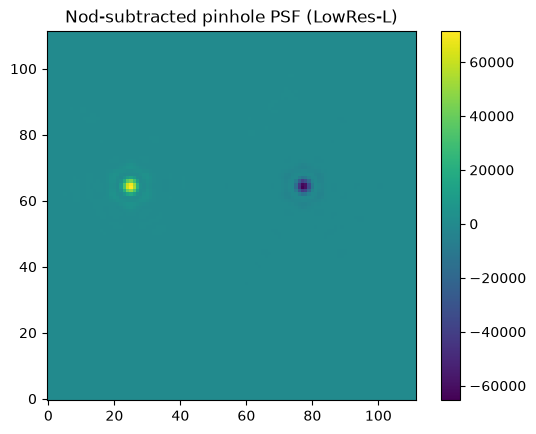

In [21]:
# Read in data
datapath = '/Users/isabelkain/Desktop/SCALES/CD5/data'

medcube = fits.getdata(f'{datapath}/ss260610_12751_opt_L2.fits')
lowcube = fits.getdata(f'{datapath}/lowres_ps_dsub.fits')
nrmcube = fits.getdata(f'{datapath}/NRM-C-1.2m_sumim_cube_fullDRP.fits')

# Define some optical parameters
lensletscale = 341. # 341 um/lenslet
f_number = 320. # f/# at the front surface of the lenslet array

# Peek at data
plt.imshow(lowcube[10], origin='lower')
plt.colorbar()
plt.title('Nod-subtracted pinhole PSF (LowRes-L)')

In [23]:
# Measure center of PSF for ever wavelength slice in cube

wave_list = np.linspace(2.8, 4.25, 54)
xcen_list = []
ycen_list = []

for ix in np.arange(0, len(wave_list), step=1):
    
    # Run PSF model fitting
    lslice = lowcube[ix]
    lwav = wave_list[ix]

    psfphot = fit_2dgaussian_assym(lslice, xypos=(25., 65.), fwhm=1.5, fit_shape=11, fix_fwhm=False)
    phot_tbl = psfphot.results

    # Best fit mean
    x_fit = phot_tbl['x_fit'].value[0]
    y_fit = phot_tbl['y_fit'].value[0]

    # Record results
    xcen_list.append( x_fit )
    ycen_list.append( y_fit )
    

## Calc Strehl

0.7420507379163519


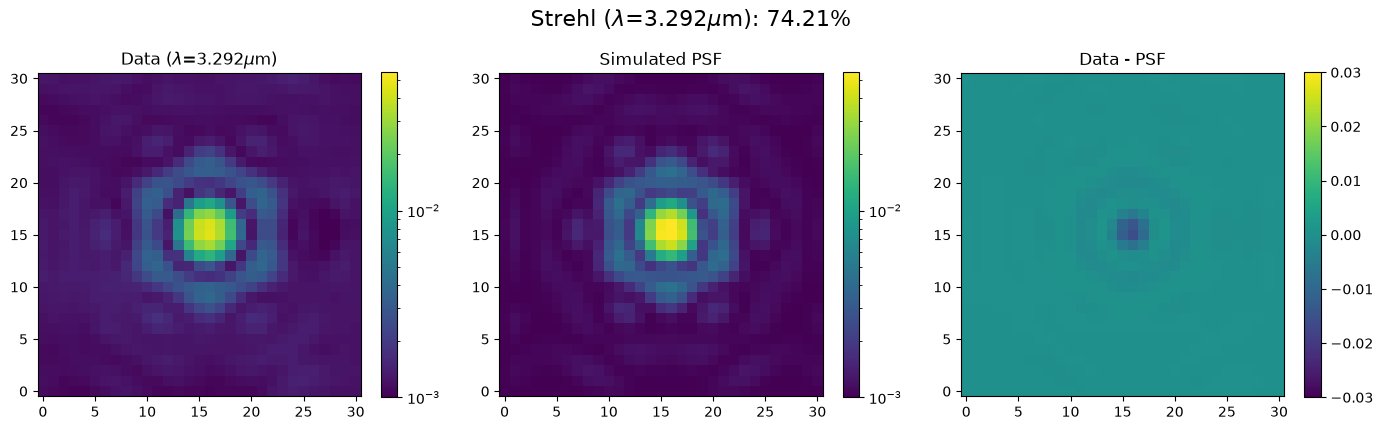

In [24]:
## ~~~ Calculate Strehl ratio for monochromatic PSF ~~~ ##

# Isolate single wavelength
ix = 18
lslice = lowcube[ix]
lwav = wave_list[ix]
xc, yc = xcen_list[ix], ycen_list[ix]

# Isolate postage stamp around real PSF, normalize s.t. postage stamp sums to 1.
data = lslice[int(yc)-15:int(yc)+15+1, int(xc)-15:int(xc)+15+1]
data /= np.sum(data)

# Do Gaussian fitting on PSF to find center
psfphot = fit_2dgaussian_assym(data, xypos=tuple(centroid_com(data)), fwhm=4.0, fit_shape=11, fix_fwhm=False)
x_fit = psfphot.results['x_fit'].value[0]
y_fit = psfphot.results['y_fit'].value[0]

# Do Strehl calculation
strehl, psf = calc_strehl(data=data, xcen=x_fit, ycen=y_fit, wav=lwav, f_number=f_number, pixel_pitch=lensletscale)
print(strehl)


0.807269315189722


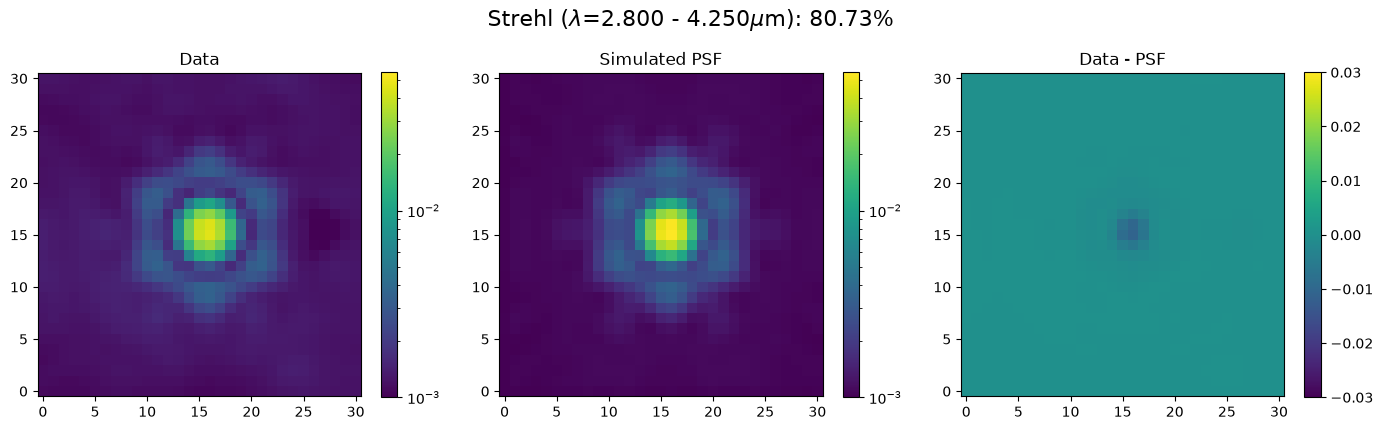

In [25]:
## ~~~ Calculate Strehl ratio for broadband PSF ~~~ ##

smush = np.sum(lowcube, axis=0)
xc, yc = np.average(xcen_list), np.average(ycen_list)

# Isolate postage stamp around real PSF, normalize s.t. postage stamp sums to 1.
data = smush[int(yc)-15:int(yc)+15+1, int(xc)-15:int(xc)+15+1]
data /= np.sum(data)

# Do Gaussian fitting on PSF to find center
psfphot = fit_2dgaussian_assym(data, xypos=tuple(centroid_com(data)), fwhm=4.0, fit_shape=11, fix_fwhm=False)
x_fit = psfphot.results['x_fit'].value[0]
y_fit = psfphot.results['y_fit'].value[0]


strehl_b, psf_b = calc_strehl_broadband(data=data, xcen=x_fit, ycen=y_fit, wavelengths=wave_list, 
                                        f_number=f_number, pixel_pitch=lensletscale)
print(strehl_b)

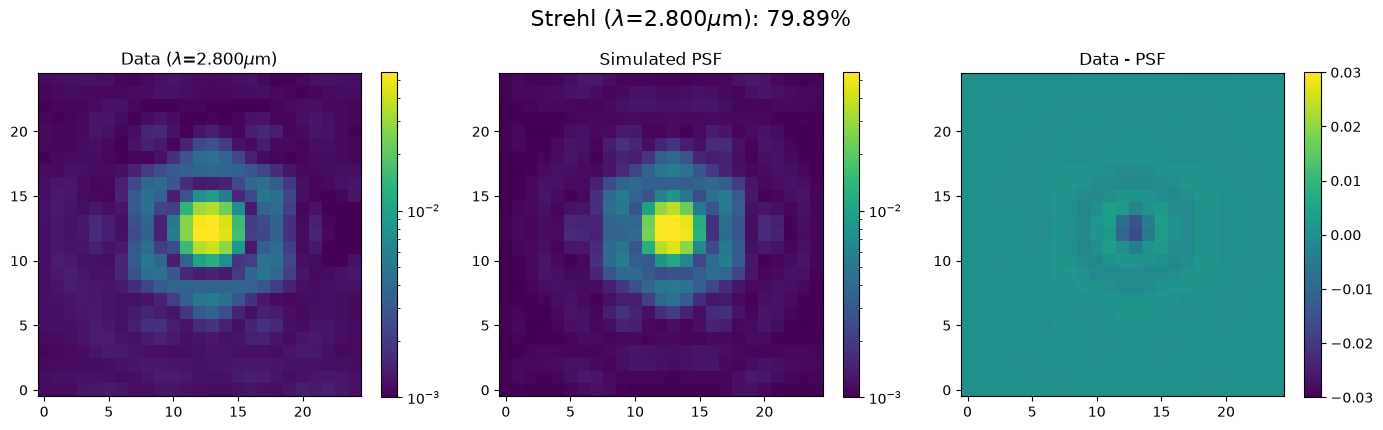

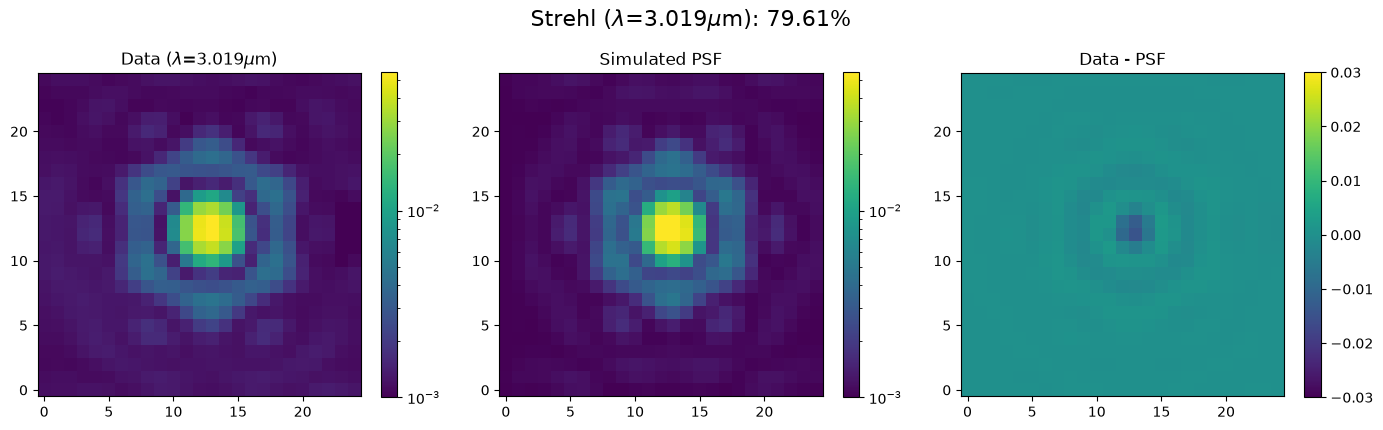

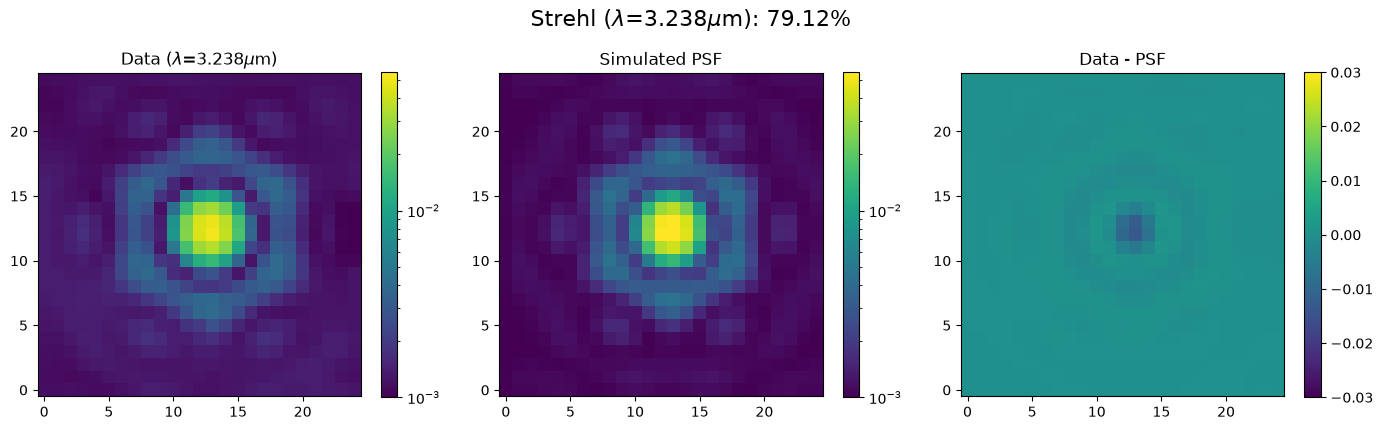

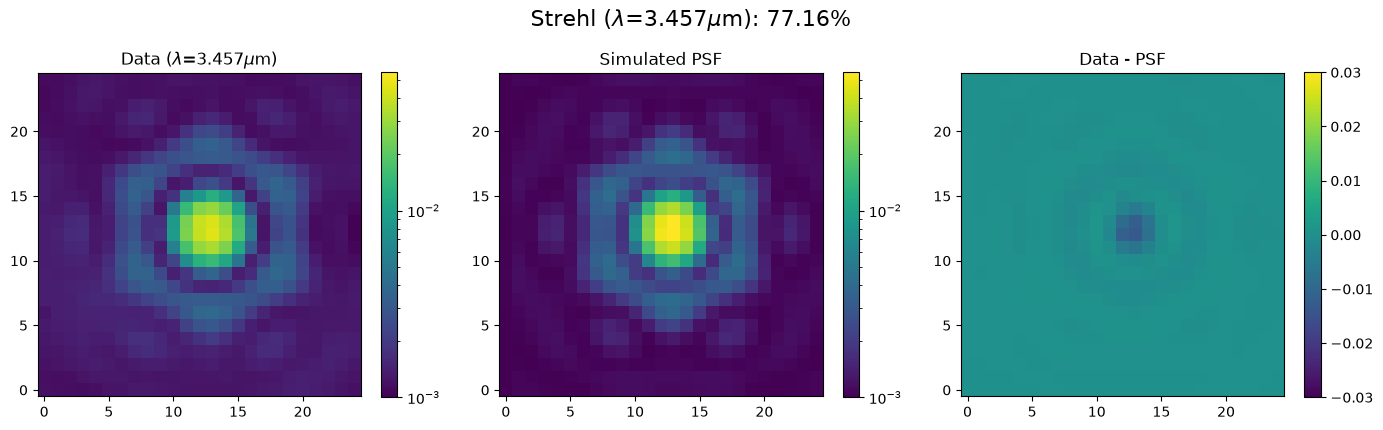

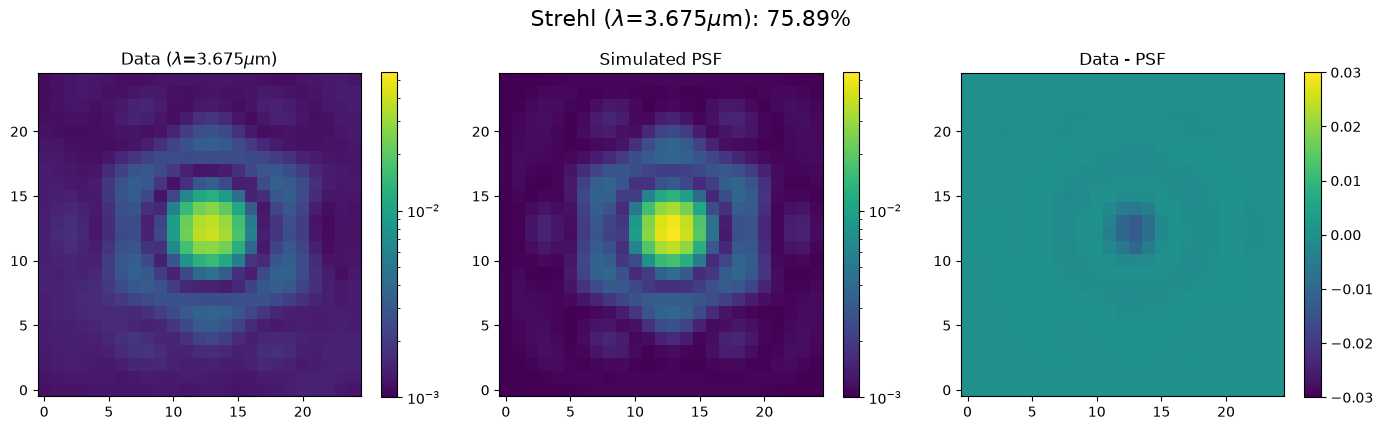

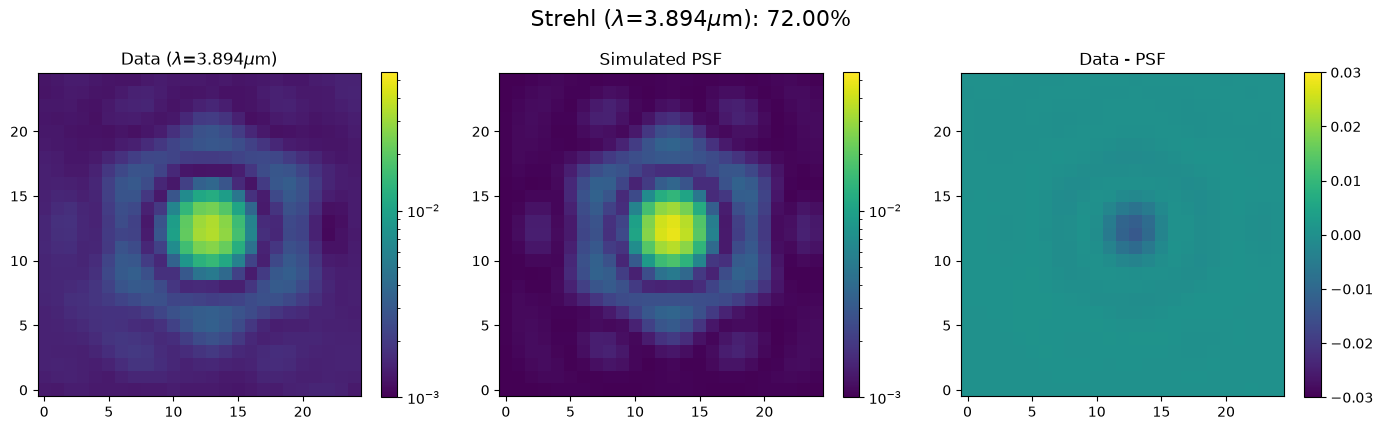

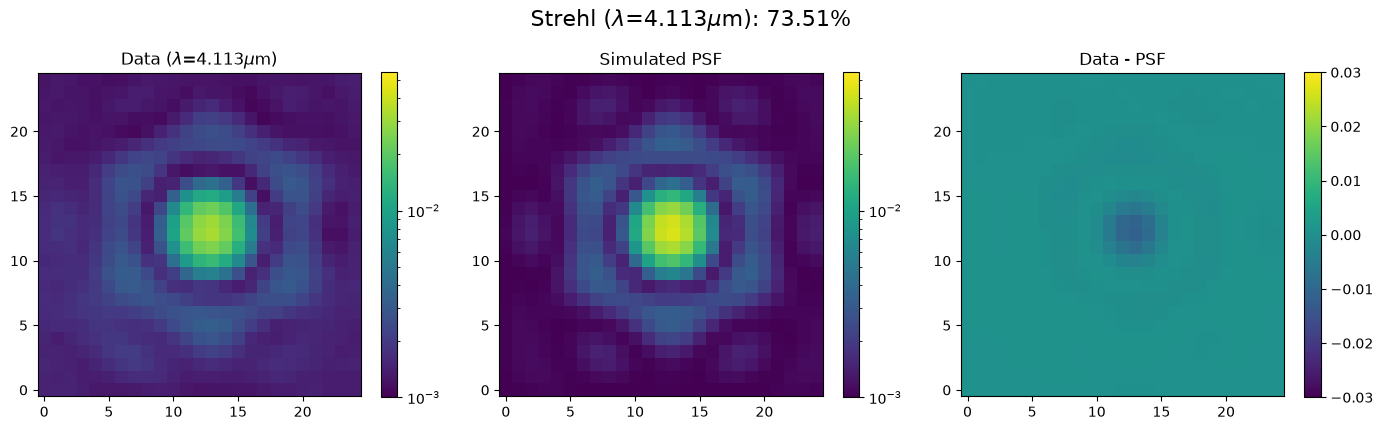

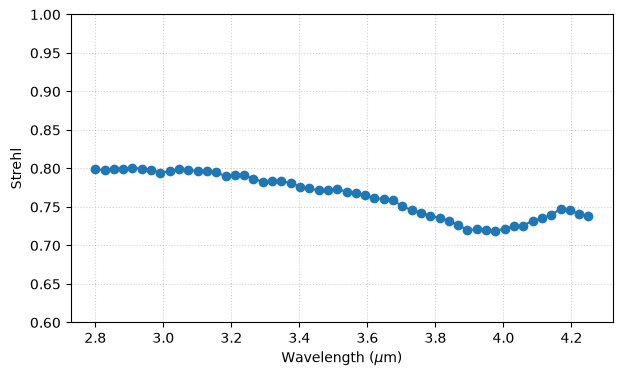

In [32]:
## ~~~ Calculate Strehl ratio for every wavelength slice of lowres pinhole cube ~~~ ##

lwavelengths = np.linspace(2.8, 4.25, 54) # I'm not sure what exactly 
strehl_list = []
psf_list = []

# # Find centroid for first PSF; should remain stable through wavelength space

# inity, initx = np.where(lowcube[0]==np.max(lowcube[0])) #centroid_com(lslice)
# xc, yc = centroid_1dg(lowcube[0, :, :60])

# Isolate single wavelength

for i in range(np.shape(lowcube)[0]):
# for i in range(0,1):
    
    doplot = False
    if i%8==0: doplot=True

    lslice = np.copy( lowcube[i] )
    lwav = np.copy( lwavelengths[i] )
    xc, yc = xcen_list[i], ycen_list[i]

    # Isolate postage stamp around real PSF, normalize s.t. postage stamp sums to 1.
#     data = lslice[int(yc)-15:int(yc)+15+1, int(xc)-15:int(xc)+15+1]
    data = np.copy( lslice[int(yc)-12:int(yc)+12+1, int(xc)-12:int(xc)+12+1] )
#     print('Max data value:', np.max(data))
    data /= np.sum(data)

    # Do Gaussian fitting on PSF to find center
    psfphot = fit_2dgaussian_assym(data, xypos=tuple(centroid_com(data)), fwhm=4.0, fit_shape=11, fix_fwhm=False)
    x_fit = psfphot.results['x_fit'].value[0]
    y_fit = psfphot.results['y_fit'].value[0]

    # Do Strehl calculation
    s, p = calc_strehl(data=data, xcen=x_fit, ycen=y_fit, wav=lwav, f_number=320., pixel_pitch=lensletscale, plot=doplot)
    strehl_list.append(s)
    psf_list.append(p)
    
plt.figure(figsize=(7,4))
plt.plot(lwavelengths, strehl_list, 'o-')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Strehl')
plt.ylim(0.6, 1.0)
plt.grid(ls=':', alpha=0.6)

## Pupil rotation example

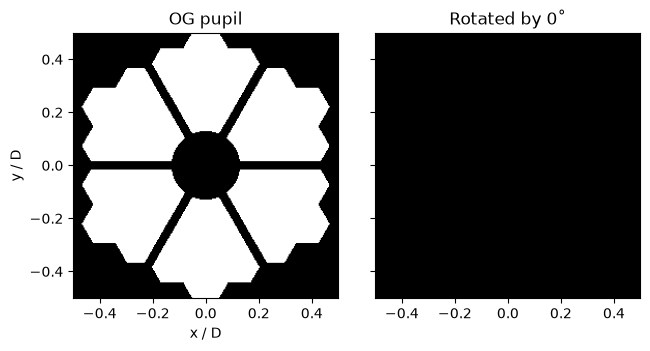

In [34]:
pupil_grid = make_pupil_grid(256)

lyot3_ap = make_lyot_stop(whichmask='3%')
lyot3_ap_rot = make_rotated_aperture(lyot3_ap, np.deg2rad(0.))

lyot3_pupil = lyot3_ap(pupil_grid)
lyot3_pupil_rot = lyot3_ap_rot(pupil_grid)

# Plot
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
plt.tight_layout()

im1 = imshow_field(lyot3_pupil, cmap='gray', ax=ax[0], vmin=0.0, vmax=1.)
im2 = imshow_field(lyot3_pupil_rot, cmap='gray', ax=ax[1], vmin=0.0, vmax=1.)

# plt.colorbar()
ax[0].set_title('OG pupil')
ax[1].set_title('Rotated by 0˚')
ax[0].set_xlabel('x / D')
ax[0].set_ylabel('y / D')
plt.show()


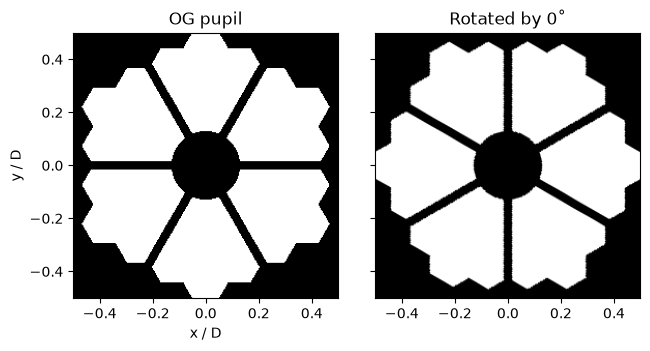

In [35]:
from skimage.transform import rotate

def rotate_field(f, theta):
    return Field(rotate(f.shaped, theta).ravel(), f.grid)

pupil_grid = make_pupil_grid(256)
lyot3_ap = make_lyot_stop(whichmask='3%')
lyot3_pupil_rot = rotate_field(lyot3_ap(pupil_grid), 30)

# Plot
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
plt.tight_layout()

im1 = imshow_field(lyot3_pupil, cmap='gray', ax=ax[0], vmin=0.0, vmax=1.)
im2 = imshow_field(lyot3_pupil_rot, cmap='gray', ax=ax[1], vmin=0.0, vmax=1.)

# plt.colorbar()
ax[0].set_title('OG pupil')
ax[1].set_title('Rotated by 0˚')
ax[0].set_xlabel('x / D')
ax[0].set_ylabel('y / D')
plt.show()